<a href="https://colab.research.google.com/github/kamilal-hub/DSA210-TERM-PROJECT/blob/main/dsa210.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pytrends

In [2]:
!wget https://datasets.imdbws.com/title.basics.tsv.gz
!wget https://datasets.imdbws.com/title.ratings.tsv.gz

--2026-04-14 14:11:00--  https://datasets.imdbws.com/title.basics.tsv.gz
Resolving datasets.imdbws.com (datasets.imdbws.com)... 54.230.253.69, 54.230.253.32, 54.230.253.42, ...
Connecting to datasets.imdbws.com (datasets.imdbws.com)|54.230.253.69|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 220384621 (210M) [binary/octet-stream]
Saving to: ‘title.basics.tsv.gz’

title.basics.tsv.gz 100%[===================>] 210.17M   190MB/s    in 1.1s    

2026-04-14 14:11:01 (190 MB/s) - ‘title.basics.tsv.gz’ saved [220384621/220384621]

--2026-04-14 14:11:01--  https://datasets.imdbws.com/title.ratings.tsv.gz
Resolving datasets.imdbws.com (datasets.imdbws.com)... 54.230.253.69, 54.230.253.32, 54.230.253.42, ...
Connecting to datasets.imdbws.com (datasets.imdbws.com)|54.230.253.69|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8389569 (8.0M) [binary/octet-stream]
Saving to: ‘title.ratings.tsv.gz’

title.ratings.tsv.g 100%[===================>] 

In [3]:
import pandas as pd

basics = pd.read_csv('title.basics.tsv.gz', sep='\t', low_memory=False, na_values='\\N')
ratings = pd.read_csv('title.ratings.tsv.gz', sep='\t', low_memory=False, na_values='\\N')

tv_series = basics[basics['titleType'] == 'tvSeries']

merged = pd.merge(tv_series, ratings, on='tconst')

merged['startYear'] = pd.to_numeric(merged['startYear'], errors='coerce')
final_list = merged[(merged['startYear'] >= 2010) & (merged['startYear'] <= 2025)]

top_250 = final_list.sort_values(by='numVotes', ascending=False).head(250)


print(f"Successfully filtered {len(top_250)} series.")
top_250[['primaryTitle', 'averageRating', 'numVotes', 'startYear']].head(10)

Successfully filtered 250 series.


,primaryTitle,averageRating,numVotes,startYear
26425,Game of Thrones,9.2,2604262,2011.0
90824,Stranger Things,8.6,1690011,2016.0
48207,The Walking Dead,8.1,1192307,2010.0
46591,Sherlock,9.0,1085895,2010.0
35406,The Boys,8.6,851591,2019.0
74594,Better Call Saul,9.0,828336,2015.0
66035,Peaky Blinders,8.7,770679,2013.0
31345,Squid Game,7.9,756418,2021.0
64690,True Detective,8.8,752027,2014.0
59182,Black Mirror,8.7,735037,2011.0


In [4]:
import pandas as pd
from pytrends.request import TrendReq
import time
import random

pytrends = TrendReq(hl='en-US', tz=360)

series_list = top_250['primaryTitle'].head(250).tolist()
all_trends = []

print("Starting data collection with RETRY mechanism for 250 series...")

for name in series_list:
    success = False
    retries = 0
    max_retries = 3

    while not success and retries < max_retries:
        try:
            pytrends.build_payload([name], timeframe='2010-01-01 2025-12-31')
            df = pytrends.interest_over_time()

            if not df.empty:
                series_trend = df[name].reset_index()
                series_trend['title'] = name
                all_trends.append(series_trend)
                print(f"--- {name} successfully fetched.")

            success = True
            time.sleep(random.uniform(25, 35))

        except Exception as e:
            retries += 1
            penalty_wait = 60 * retries
            print(f"!!! Error 429 for {name} (Attempt {retries}/{max_retries}).")

            if retries < max_retries:
                print(f"Google is angry. Hiding for {penalty_wait} seconds before retrying {name}...")
                time.sleep(penalty_wait)
            else:
                print(f"Skipping {name} after {max_retries} failed attempts. Moving on.")

if all_trends:
    final_trends_df = pd.concat(all_trends, ignore_index=True)

    final_trends_df.to_csv('tv_series_trends_150.csv', index=False)
    print("Data collection complete and saved to CSV!")

Starting data collection with RETRY mechanism for 250 series...
!!! Error 429 for Game of Thrones (Attempt 1/3).
Google is angry. Hiding for 60 seconds before retrying Game of Thrones...
--- Game of Thrones successfully fetched.
--- Stranger Things successfully fetched.
!!! Error 429 for The Walking Dead (Attempt 1/3).
Google is angry. Hiding for 60 seconds before retrying The Walking Dead...
--- The Walking Dead successfully fetched.
--- Sherlock successfully fetched.
--- The Boys successfully fetched.
--- Better Call Saul successfully fetched.
--- Peaky Blinders successfully fetched.
!!! Error 429 for Squid Game (Attempt 1/3).
Google is angry. Hiding for 60 seconds before retrying Squid Game...
--- Squid Game successfully fetched.
!!! Error 429 for True Detective (Attempt 1/3).
Google is angry. Hiding for 60 seconds before retrying True Detective...
--- True Detective successfully fetched.
!!! Error 429 for Black Mirror (Attempt 1/3).
Google is angry. Hiding for 60 seconds before ret

In [5]:
final_trends_df.to_csv('tv_series_google_trends.csv', index=False)
print("Data successfully saved to 'tv_series_google_trends.csv'!")

Data successfully saved to 'tv_series_google_trends.csv'!


In [6]:

peak_interests = []
for title in final_trends_df['title'].unique():
    peak_val = final_trends_df[final_trends_df['title'] == title][title].max()
    peak_interests.append({'primaryTitle': title, 'peak_search': peak_val})

summary_trends = pd.DataFrame(peak_interests)
combined_df = pd.merge(top_250, summary_trends, on='primaryTitle')

print(f"Merged data for {len(combined_df)} series.")
combined_df[['primaryTitle', 'averageRating', 'peak_search']].head()

Merged data for 249 series.


,primaryTitle,averageRating,peak_search
0,Game of Thrones,9.2,100.0
1,Stranger Things,8.6,100.0
2,The Walking Dead,8.1,100.0
3,Sherlock,9.0,100.0
4,The Boys,8.6,100.0


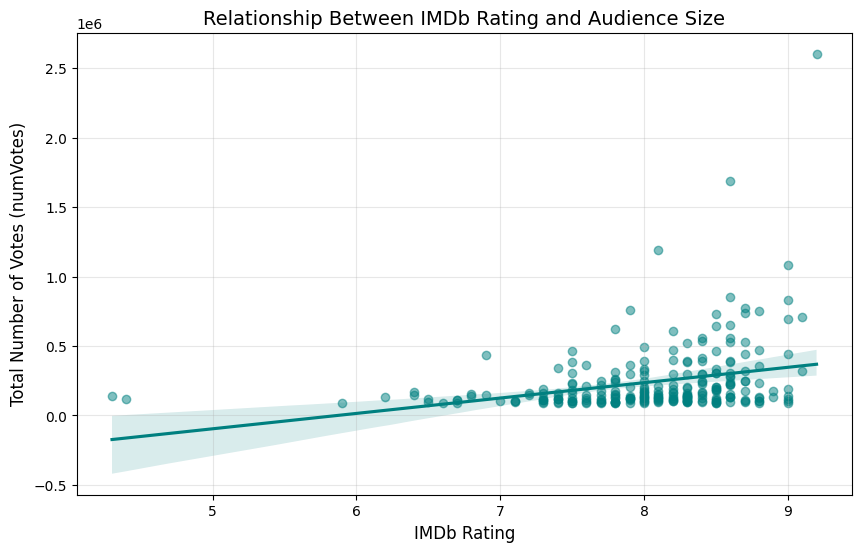

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(data=combined_df, x='averageRating', y='numVotes', color='teal', scatter_kws={'alpha':0.5})
plt.title('Relationship Between IMDb Rating and Audience Size', fontsize=14)
plt.xlabel('IMDb Rating', fontsize=12)
plt.ylabel('Total Number of Votes (numVotes)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
correlation = combined_df['averageRating'].corr(combined_df['numVotes'])

print("-" * 45)
print("HYPOTHESIS TEST RESULTS ")
print(f"Correlation between Rating and Popularity: {correlation:.2f}")
print("-" * 45)

if correlation > 0.4:
    print("Interpretation: There is a significant positive correlation. Quality often leads to popularity.")
else:
    print("Interpretation: The correlation is weak. A high rating does not guarantee mass-market popularity.")

---------------------------------------------
HYPOTHESIS TEST RESULTS 
Correlation between Rating and Popularity: 0.30
---------------------------------------------
Interpretation: The correlation is weak. A high rating does not guarantee mass-market popularity.
